# Reference-free HVSR quality assessment

Process the SAC recordings independently: **no reference curve is loaded or used**. Evaluate a bounded set of physically reasonable processing choices using the SESAME (2004) checks implemented by hvsrpy. Reliability requires **3/3** and clarity requires **at least 5/6**. A passing score does not prove a unique resonance or geological interpretation.

The search uses non-overlapping windows, no filtering, quadratic horizontal combination, a fixed broad frequency range, and no manually narrowed peak band. It tests window length, smoothing, raw-signal anti-trigger, and moderate frequency-domain rejection (2.5 standard deviations). It does not minimize misfit to another program, maximize peak amplitude, or tighten rejection until every criterion passes.

Selection rules are declared before the search: retain at least 70% of available windows, require 30 accepted windows, require coverage from f0/4 to 4*f0, and require the same local peak to remain within 10% across four chronological blocks. Rank eligible profiles by reliability, clarity, global-peak stability, retained fraction, then longer windows and lower amplitude scatter. A competing stronger peak in a time block is reported separately, never hidden by local-peak tracking.

This is a dataset-specific recommendation, not proof of a universally best configuration. Inspect failed criteria, rejected windows, alternative peaks and temporal behaviour before interpretation. Select the **ciudad-perdida** kernel and run all cells.

In [1]:
import hashlib
import importlib
import sys
from importlib.metadata import version
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / 'utils' / 'hvsr_tools.py').is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Run from inside the project repository.')
sys.path.insert(0, str(PROJECT_ROOT))
import utils.hvsr_tools as hv
hv = importlib.reload(hv)
if Path(hv.__file__).resolve() != PROJECT_ROOT / 'utils' / 'hvsr_tools.py':
    raise ImportError('An unrelated utils module is loaded. Restart the kernel.')
print('Python:', sys.executable)
print('hvsrpy:', version('hvsrpy'))

Python: /home/orincon/miniconda3/envs/ciudad-perdida/bin/python
hvsrpy: 2.1.0


In [2]:
DATA_DIR = PROJECT_ROOT / 'HVMATLAB'
INPUT_FILES = {c: DATA_DIR / f'00P2-2_WA.WAU40..HH{c}.D.2020.281.sac' for c in 'NEZ'}
OUTPUT_DIR = PROJECT_ROOT / 'main' / '02_analysis_hv' / 'outputs_sesame_optimization'
OUTPUT_PREFIX = '00P2-2'
MIN_RETAINED_FRACTION = 0.70
MIN_WINDOWS = 30
TIME_BLOCKS = 4
MAX_TRACKED_PEAK_DEVIATION_PCT = 10.0
MAX_GLOBAL_PEAK_DEVIATION_PCT = 10.0

base = hv.HVSRParams(
    window_selection='grid', window_gap_samples=0,
    window_length_s=32.0, overlap_pct=0.0,
    anti_trigger=False, sta_lta_mode='continuous',
    sta_s=2.0, lta_s=25.0, sta_lta_min=0.2, sta_lta_max=2.0,
    sta_lta_components=('N', 'E', 'Z'), sta_lta_amplitude='abs',
    sta_lta_on_filtered=False, clip_threshold_pct=None,
    detrend='constant', filter_corners_hz=(None, None),
    taper=True, taper_pct=5.0, taper_pct_per_side=True,
    fft_zero_padding=False, smoothing='konno_and_ohmachi',
    smoothing_bandwidth=40.0, smoothing_scale='linear', smoothing_truncate=False,
    horizontal_combination='squared_average',
    fmin=0.2, fmax=45.0, frequency_spacing='log', n_frequencies=800,
    peak_range_hz=None, peak_method='find_peaks',
    window_peak_selection='independent', window_peak_range_hz=None,
    distribution='lognormal', frequency_domain_rejection=False, fdr_n=2.5,
)
SWEEP_GRID = {
    'window_length_s': [16.0, 32.0, 64.0, 128.0],
    'smoothing_bandwidth': [20.0, 30.0, 40.0],
    'smoothing_scale': ['linear', 'log'],
    'anti_trigger': [False, True],
    'frequency_domain_rejection': [False, True],
}
base.validate()
record = hv.load_record(INPUT_FILES)
display(record.meta)
print('Profiles to evaluate:', int(np.prod([len(v) for v in SWEEP_GRID.values()])))

{'file name(s)': ['/home/orincon/ciudad-perdida-hvsr/HVMATLAB/00P2-2_WA.WAU40..HHN.D.2020.281.sac',
  '/home/orincon/ciudad-perdida-hvsr/HVMATLAB/00P2-2_WA.WAU40..HHE.D.2020.281.sac',
  '/home/orincon/ciudad-perdida-hvsr/HVMATLAB/00P2-2_WA.WAU40..HHZ.D.2020.281.sac'],
 'deployed degrees from north': 0.0,
 'current degrees from north': 0.0,
 'station': '00P2-2',
 'starttime': '2020-10-07T08:18:39.000000Z',
 'sampling_rate_hz': 100.0,
 'duration_s': 28160.99}

Profiles to evaluate: 96


In [3]:
baseline = hv.run_hvsr(record, base)
baseline_quality = hv.assess_sesame_quality(baseline, time_blocks=TIME_BLOCKS)
sweep = hv.parameter_sweep(record, base, SWEEP_GRID,
                          assess_sesame=True, time_blocks=TIME_BLOCKS)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sweep.to_csv(OUTPUT_DIR / f'{OUTPUT_PREFIX}_all_profiles.csv', index=False)
errors = sweep['error'].notna() if 'error' in sweep else pd.Series(False, index=sweep.index)
if errors.any():
    display(sweep.loc[errors, [*SWEEP_GRID, 'error']])
    print('WARNING: failed profiles are saved and excluded, not assigned successful scores.')
successful = sweep.loc[~errors].copy()
if successful.empty:
    raise RuntimeError('Every profile failed. Inspect the saved profile table.')
successful['global_peak_stable'] = successful['block_global_max_deviation_pct'] <= MAX_GLOBAL_PEAK_DEVIATION_PCT
eligible = successful.loc[
    (successful['retained_fraction'] >= MIN_RETAINED_FRACTION)
    & (successful['n_windows'] >= MIN_WINDOWS)
    & successful['frequency_coverage_complete'].eq(True)
    & successful['time_blocks_complete'].eq(True)
    & (successful['block_tracked_max_deviation_pct'] <= MAX_TRACKED_PEAK_DEVIATION_PCT)
].copy()
if eligible.empty:
    raise RuntimeError('No profile satisfies the declared retention/coverage/stability rules. Inspect the diagnostics; do not silently relax them.')
ranked = eligible.sort_values(
    ['reliability_count', 'clarity_count', 'global_peak_stable', 'retained_fraction',
     'window_length_s', 'sigma_a_at_peak', 'block_tracked_max_deviation_pct'],
    ascending=[False, False, False, False, False, True, True], kind='stable',
).reset_index(drop=True)
ranked.to_csv(OUTPUT_DIR / f'{OUTPUT_PREFIX}_ranked_profiles.csv', index=False)
display(ranked[[*SWEEP_GRID, 'n_windows', 'retained_fraction', 'reliability_count',
                'clarity_count', 'f0_mean_curve_hz', 'A0_mean_curve',
                'block_global_max_deviation_pct', 'block_tracked_max_deviation_pct']].head(15))

windows 880/880  |  f0 = 10.13 Hz, A0 = 5.18  |  f0 windows = 7.74 Hz  [0.5 s]


,window_length_s,smoothing_bandwidth,smoothing_scale,anti_trigger,frequency_domain_rejection,n_windows,retained_fraction,reliability_count,clarity_count,f0_mean_curve_hz,A0_mean_curve,block_global_max_deviation_pct,block_tracked_max_deviation_pct
0,32.0,40.0,linear,False,False,880,1.000000,3,5,10.128678,5.181506,42.260135,1.346571
1,16.0,40.0,linear,False,False,1760,1.000000,3,5,10.128678,5.371010,40.344501,0.675568
2,16.0,40.0,linear,False,True,1513,0.859659,3,5,10.128678,5.468724,40.344501,0.675568
3,16.0,40.0,linear,True,False,1353,0.768750,3,5,10.128678,5.447988,40.344501,0.675568
4,128.0,40.0,log,False,False,220,1.000000,3,4,9.924783,5.031154,52.237729,0.680163
5,128.0,30.0,log,False,False,220,1.000000,3,4,9.791139,4.833354,53.273193,0.680163
6,128.0,40.0,linear,False,False,220,1.000000,3,4,10.060252,4.865910,47.164398,0.680163
7,128.0,30.0,linear,False,False,220,1.000000,3,4,9.924783,4.587254,48.165355,0.680163
8,128.0,20.0,linear,False,False,220,1.000000,3,4,9.529225,4.326428,54.315700,2.054398
9,128.0,20.0,log,False,False,220,1.000000,3,4,9.274317,4.635877,60.721347,2.054398


In [4]:
best_changes = {}
for name in SWEEP_GRID:
    value = ranked.loc[0, name]
    best_changes[name] = value.item() if isinstance(value, np.generic) else value
params = base.update(**best_changes)
result = hv.run_hvsr(record, params)
quality = hv.assess_sesame_quality(result, time_blocks=TIME_BLOCKS)
criteria = pd.DataFrame(quality['criteria'])
blocks = pd.DataFrame(quality['time_blocks'])
display(pd.Series(params.to_dict(), name='Selected parameters'))
display(criteria)
display(blocks)
display(pd.DataFrame([baseline_quality['metrics'], quality['metrics']], index=['baseline', 'selected']))
if not quality['metrics']['sesame_passed']:
    print('WARNING: the best eligible profile does not meet overall SESAME acceptance.')
if quality['metrics']['block_global_max_deviation_pct'] > MAX_GLOBAL_PEAK_DEVIATION_PCT:
    print('WARNING: the globally strongest peak changes between time blocks. The tracked local peak may be stable, but the record is not single-peak stationary.')
failed = criteria.loc[~criteria['passed'], 'criterion'].tolist()
print('Failed SESAME criteria:', failed)
sesame = result.sesame(verbose=2)

windows 880/880  |  f0 = 10.13 Hz, A0 = 5.18  |  f0 windows = 7.74 Hz  [0.4 s]


window_length_s                              32.0
overlap_pct                                   0.0
window_selection                             grid
window_gap_samples                              0
anti_trigger                                False
sta_lta_mode                           continuous
sta_s                                         2.0
lta_s                                        25.0
sta_lta_min                                   0.2
sta_lta_max                                   2.0
sta_lta_components                      (N, E, Z)
sta_lta_amplitude                             abs
sta_lta_on_filtered                         False
clip_threshold_pct                           None
filter_corners_hz                    (None, None)
filter_order                                    5
detrend                                  constant
orient_to_degrees_from_north                 None
taper                                        True
taper_pct                                     5.0


,criterion,description,value,comparison,threshold,passed
0,R1,Cycles per window,324.117682,>,10.00,True
1,R2,Total cycles,285223.560563,>,200.00,True
2,R3,"Maximum amplitude scatter in [f0/2, 2*f0]",1.449834,<,2.00,True
3,C1,Minimum amplitude below peak / A0,0.244439,<,0.50,True
4,C2,Minimum amplitude above peak / A0,0.255611,<,0.50,True
5,C3,Peak amplitude,5.181506,>,2.00,True
6,C4,Maximum relative shift of +/-1 sigma peaks,0.006756,<,0.05,True
7,C5,Window-peak frequency standard deviation / f0,0.359581,<,0.05,False
8,C6,Amplitude scatter at f0,1.197978,<,1.58,True


,block,start_s,end_s,n_windows,f0_global_hz,A0_global,f0_tracked_hz,A0_tracked
0,1,0.0000,7040.2475,221,14.409070,4.884861,10.128678,4.713370
1,2,7040.2475,14080.4950,220,10.128678,5.351290,10.128678,5.351290
2,3,14080.4950,21120.7425,220,9.992288,5.165797,9.992288,5.165797
3,4,21120.7425,28160.9900,219,10.128678,5.574813,10.128678,5.574813


,reliability_count,clarity_count,sesame_passed,retained_fraction,peak_coverage_fraction,frequency_coverage_complete,fn_std_hz,fn_std_relative,sigma_a_at_peak,block_global_max_deviation_pct,...,time_blocks_complete,R1,R2,R3,C1,C2,C3,C4,C5,C6
baseline,3,5,True,1.0,1.0,True,3.642078,0.359581,1.197978,42.260135,...,True,True,True,True,True,True,True,True,False,True
selected,3,5,True,1.0,1.0,True,3.642078,0.359581,1.197978,42.260135,...,True,True,True,True,True,True,True,True,False,True


Failed SESAME criteria: ['C5']
Considering only frequencies between 0.200 and 45.000 Hz.
    Lower frequency limit is 0.200 Hz.
    Upper frequency limit is 45.000 Hz.
Assessing SESAME (2004) reliability criteria ... 
  Criteria i): Pass
    fnmc=10.129 is > 10/windowlength=0.312
  Criteria ii): Pass
    nc(fnmc)=285224 is > 200
  Criteria iii): Pass
    sigma_a(f)=1.450 is < 2
  The chosen peak PASSES the peak reliability criteria, with 3 of 3.
Assessing SESAME (2004) clarity criteria ... 
Considering only frequencies between 0.200 and 45.000 Hz.
    Lower frequency limit is 0.200 Hz.
    Upper frequency limit is 45.000 Hz.
  Criteria i): Pass
    min(A[fnmc/4,fnmc])=1.267 is < A0[fnmc]/2=5.182/2=2.591
  Criteria ii): Pass
    min(A[fnmc,fnmc*4])=1.324 is < A0[fnmc]/2=5.182/2=2.591
  Criteria iii): Pass
    A0[fnmc]=5.182 is > 2.0
  Criteria iv): Pass
    fn_upper=10.129 is within 5% of fnmc=10.129.
    fn_lower=10.060 is within 5% of fnmc=10.129.
  Criteria v): Fail
    fn_std=3.642 

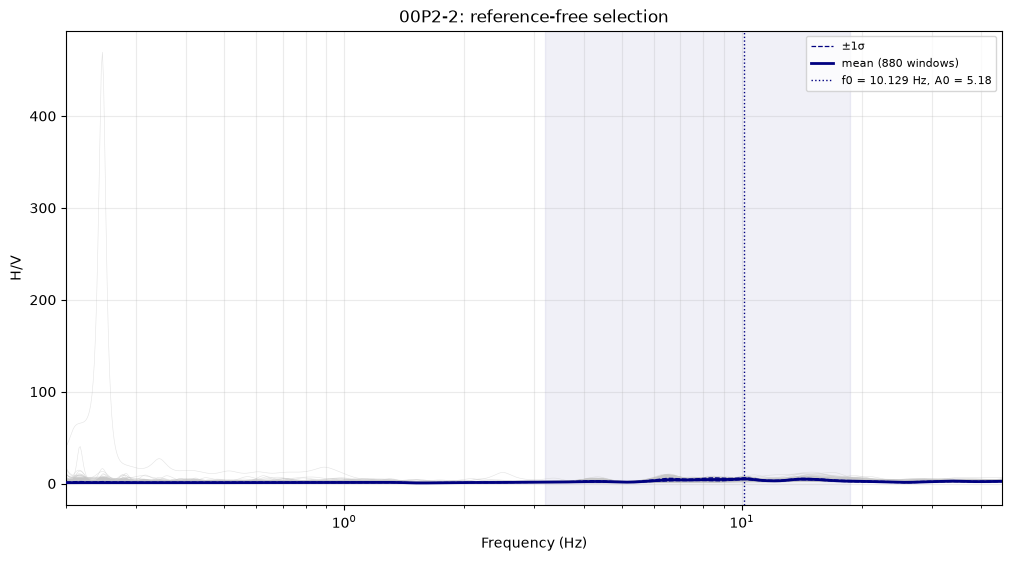

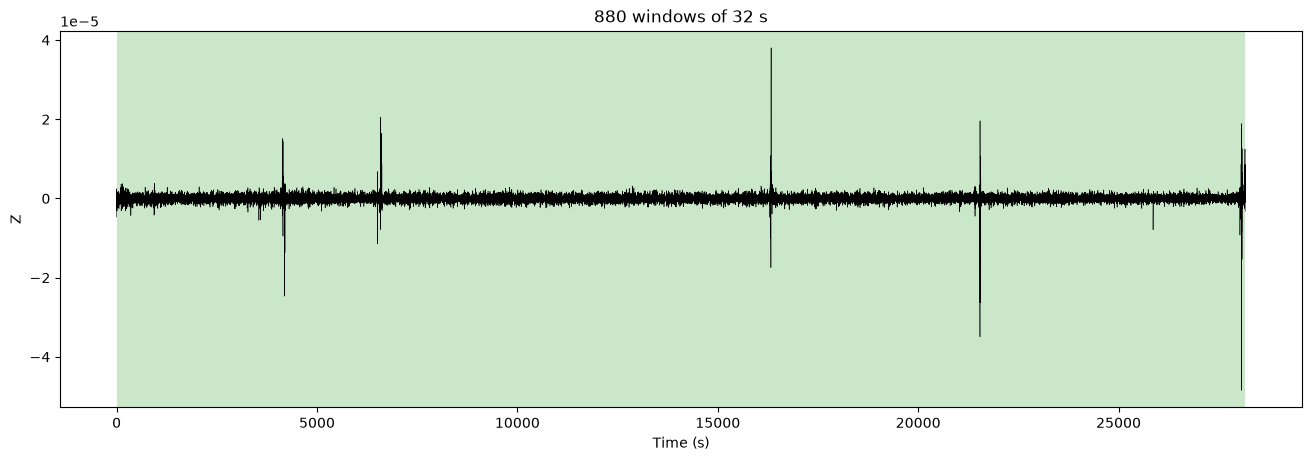

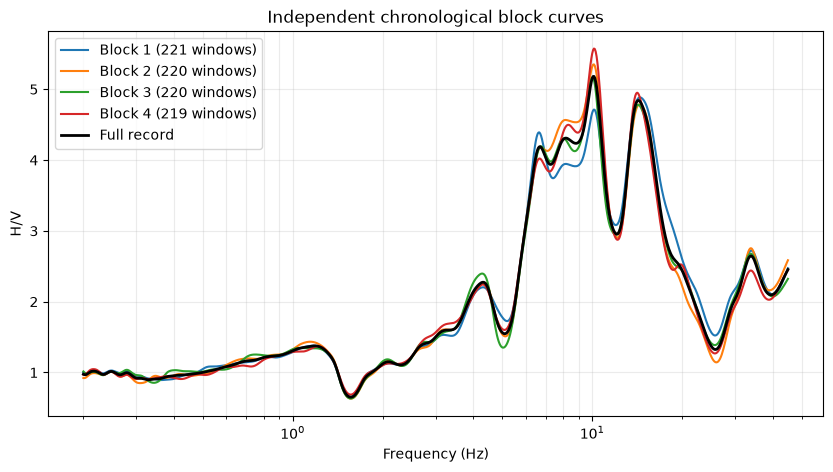

In [5]:
window_axes = hv.plot_hvsr(result, show_windows=True, title=f'{OUTPUT_PREFIX}: reference-free selection')
plt.show()
selection_figure = hv.plot_window_selection(record, result)
plt.show()
fig_blocks, ax = plt.subplots(figsize=(10, 5))
starts = result.window_starts_s[result.valid_mask]
for row in quality['time_blocks']:
    chosen = (starts >= row['start_s']) & (starts < row['end_s'])
    mean = np.exp(np.log(result.window_curves[chosen]).mean(axis=0))
    ax.plot(result.frequency, mean, label=f"Block {row['block']} ({row['n_windows']} windows)")
ax.plot(result.frequency, result.mean_curve, color='k', lw=2, label='Full record')
ax.set(xscale='log', xlabel='Frequency (Hz)', ylabel='H/V', title='Independent chronological block curves')
ax.grid(which='both', alpha=0.25)
ax.legend()
plt.show()

## Interpretation and reproducibility

Read C5 as actual frequency variability, not a parameter-tuning target. A wide distribution can reflect multiple peaks or changing ambient-noise sources. A 5/6 clarity result is accepted by SESAME, but report the failing criterion. The global-peak and tracked-peak block diagnostics distinguish amplitude dominance from motion of the same local peak. These blocks are a stability diagnostic on the same recording, **not an external validation dataset**.

All profiles, including failures, are saved. The recommendation prioritizes preservation of data rather than aggressive rejection. For another site, review the broad frequency limits and the search bounds based on sampling, duration and resolution, not a desired answer.

In [6]:
def sha256(path):
    with Path(path).open('rb') as stream:
        return hashlib.file_digest(stream, 'sha256').hexdigest()

provenance = {
    'python': sys.version,
    'packages': {name: version(name) for name in ('hvsrpy', 'obspy', 'numpy', 'scipy', 'pandas')},
    'module_sha256': sha256(hv.__file__),
    'inputs': {c: {'path': str(p), 'sha256': sha256(p)} for c, p in INPUT_FILES.items()},
    'reference_used': False,
}
selection_policy = {
    'minimum_retained_fraction': MIN_RETAINED_FRACTION, 'minimum_windows': MIN_WINDOWS,
    'time_blocks': TIME_BLOCKS, 'max_tracked_peak_deviation_pct': MAX_TRACKED_PEAK_DEVIATION_PCT,
    'max_global_peak_deviation_pct': MAX_GLOBAL_PEAK_DEVIATION_PCT,
    'search_grid': SWEEP_GRID, 'profiles_evaluated': len(sweep), 'eligible_profiles': len(ranked),
    'ranking': 'reliability, clarity, global stability, retention, longer windows, lower amplitude scatter, tracked stability',
}
paths = hv.save_outputs(result, OUTPUT_DIR, prefix=OUTPUT_PREFIX,
                        extra={'sesame_quality': quality, 'baseline_quality': baseline_quality,
                               'selection_policy': selection_policy, 'provenance': provenance})
criteria.to_csv(OUTPUT_DIR / f'{OUTPUT_PREFIX}_sesame_criteria.csv', index=False)
blocks.to_csv(OUTPUT_DIR / f'{OUTPUT_PREFIX}_time_blocks.csv', index=False)
window_axes.figure.savefig(OUTPUT_DIR / f'{OUTPUT_PREFIX}_hvsr.png', dpi=160)
selection_figure.savefig(OUTPUT_DIR / f'{OUTPUT_PREFIX}_selection.png', dpi=160)
fig_blocks.savefig(OUTPUT_DIR / f'{OUTPUT_PREFIX}_time_blocks.png', dpi=160)
display(paths)

{'curve': PosixPath('/home/orincon/ciudad-perdida-hvsr/main/02_analysis_hv/outputs_sesame_optimization/00P2-2.hv'),
 'windows': PosixPath('/home/orincon/ciudad-perdida-hvsr/main/02_analysis_hv/outputs_sesame_optimization/00P2-2_windows.csv'),
 'summary': PosixPath('/home/orincon/ciudad-perdida-hvsr/main/02_analysis_hv/outputs_sesame_optimization/00P2-2_summary.json')}